# M&A Valuation using Real Options

Classic M&A question: when acquiring a company with potential but uncertain
synergies, how much extra should you pay? This treats the post-acquisition
expansion right as a call option, valued with Black-Scholes.

Two questions this notebook answers:

1. What's a fair premium to pay now for the option to expand later (e.g.
   cross-selling the target's products)?
2. If the seller wants a higher price, how do you structure a fair earn-out?

| Stage | Method | Purpose |
|---|---|---|
| 1 | DCF | Base valuation, no synergy |
| 2 | Black-Scholes | Value the expansion option |
| 3 | Binomial tree | Manual cross-check |
| 4 | Monte Carlo (GBM) | Probability of hitting the earn-out |
| 5 | Sensitivity matrix | Test how assumptions affect the result |

$$NPV_{\text{total}} = NPV_{\text{standalone}} + C(S, K, r, T, \sigma)$$

> All numbers are illustrative, not real company data. Calibrated to give:
> base DCF $100.0M + option value $11.05M = $111.05M total, strike (capex)
> $25.0M, ~72% earn-out probability.

## 0. Setup

Imports and consistent chart colors.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLOR_BASE = "#1a56db"     # blue  - standalone DCF
COLOR_OPTION = "#046c4e"   # green - real option value
COLOR_ACCENT = "#7c3aed"   # purple - earn-out layer

## 1. Standalone DCF (Base Valuation)

Base valuation of the target with no synergies: 5-year FCF projection
discounted at WACC, plus terminal value (Gordon Growth).

$$NPV_{\text{standalone}} = \sum_{t=1}^{n} \frac{FCFF_t}{(1+WACC)^t} + \frac{TV_n}{(1+WACC)^n}, \qquad
TV_n = \frac{FCFF_n (1+g)}{WACC - g}$$

In [2]:
def dcf_valuation(fcff, wacc, terminal_growth):
    # fcff : forecast unlevered FCF, years 1..n
    # wacc : discount rate
    # terminal_growth : perpetual growth rate after year n
    # Returns (pv_explicit, pv_terminal, total_npv, per_year_pv table)
    fcff = np.asarray(fcff, dtype=float)
    years = np.arange(1, len(fcff) + 1)
    disc_factors = 1 / (1 + wacc) ** years
    pv_fcff = fcff * disc_factors

    terminal_value = fcff[-1] * (1 + terminal_growth) / (wacc - terminal_growth)
    pv_terminal = terminal_value * disc_factors[-1]

    total_npv = pv_fcff.sum() + pv_terminal

    table = pd.DataFrame({
        "Year": years,
        "FCFF ($M)": fcff,
        "Discount Factor": disc_factors,
        "PV of FCFF ($M)": pv_fcff,
    })
    return pv_fcff.sum(), pv_terminal, total_npv, table


# Illustrative inputs, calibrated for a ~$100M base DCF
fcff_forecast = [9.0, 9.8, 10.6, 11.4, 12.2]     # $M, FCF forecast years 1-5
wacc = 0.1313                                     # WACC 13.13%
terminal_growth = 0.025                           # long-term growth 2.5%

pv_explicit, pv_terminal, npv_standalone, dcf_table = dcf_valuation(
    fcff_forecast, wacc, terminal_growth
)

print(f"PV of explicit FCFF (yrs 1-5): ${pv_explicit:,.2f}M")
print(f"PV of terminal value:          ${pv_terminal:,.2f}M")
print(f"NPV_standalone (Base DCF):     ${npv_standalone:,.2f}M")
dcf_table

PV of explicit FCFF (yrs 1-5): $36.48M
PV of terminal value:          $63.48M
NPV_standalone (Base DCF):     $99.96M


,Year,FCFF ($M),Discount Factor,PV of FCFF ($M)
0,1,9.0,0.883939,7.955449
1,2,9.8,0.781348,7.657209
2,3,10.6,0.690664,7.321035
3,4,11.4,0.610504,6.959751
4,5,12.2,0.539649,6.583713


## 2. Expansion Option Value (Black-Scholes)

After acquisition, the company has the right (not obligation) to invest
extra capex if synergies look promising — the same logic as a call option.

| Black-Scholes variable | Meaning in this M&A case |
|---|---|
| $S$ (stock price) | PV of expected synergy cash flows |
| $K$ (strike) | Capex needed to unlock the synergy |
| $\sigma$ (volatility) | Synergy uncertainty (from comparable companies) |
| $T$ (time to maturity) | Decision window for expansion |
| $r$ (risk-free rate) | Risk-free rate over period $T$ |

$$C(S,K,r,T,\sigma) = S\,N(d_1) - K e^{-rT} N(d_2), \qquad
d_1=\frac{\ln(S/K)+\left(r+\frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}, \quad
d_2 = d_1 - \sigma\sqrt{T}$$

In [3]:
def black_scholes_call(S, K, r, T, sigma):
    # European call value, plus (d1, d2) for reuse in sensitivities
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call, d1, d2


# Illustrative expansion option inputs
S_synergy = 30.25    # $M, PV of expected synergy cash flows
K_capex = 25.0        # $M, capex needed to unlock synergy
r_rf = 0.04           # risk-free rate 4%
T_years = 3.0         # decision window, 3 years
sigma_synergy = 0.35  # synergy volatility 35%

real_option_value, d1, d2 = black_scholes_call(S_synergy, K_capex, r_rf, T_years, sigma_synergy)

print(f"d1 = {d1:.4f},  d2 = {d2:.4f}")
print(f"Expansion option value: ${real_option_value:,.2f}M")

combined_offer_price = npv_standalone + real_option_value
print(f"\nBase DCF:              ${npv_standalone:,.2f}M")
print(f"Expansion option value: ${real_option_value:,.2f}M")
print(f"Total acquisition price: ${combined_offer_price:,.2f}M")

d1 = 0.8155,  d2 = 0.2093
Expansion option value: $11.05M

Base DCF:              $99.96M
Expansion option value: $11.05M
Total acquisition price: $111.01M


## 3. Cross-Check with Binomial Tree

Black-Scholes assumes lognormal returns and continuous trading. As a
cross-check, use a binomial tree (Cox-Ross-Rubinstein), which also handles
American-style exercise (expand anytime before $T$).

$$u = e^{\sigma\sqrt{\Delta t}}, \quad d = \frac{1}{u}, \quad
p = \frac{e^{r\Delta t} - d}{u - d}$$

Value computed by backward induction from the terminal payoff $\max(S_T - K, 0)$.

In [4]:
def binomial_call(S, K, r, T, sigma, n_steps=200, american=False):
    dt = T / n_steps
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    # Terminal asset prices
    j = np.arange(n_steps + 1)
    ST = S * (u ** j) * (d ** (n_steps - j))
    values = np.maximum(ST - K, 0.0)

    # Backward induction
    for step in range(n_steps - 1, -1, -1):
        values = disc * (p * values[1:] + (1 - p) * values[:-1])
        if american:
            j = np.arange(step + 1)
            St = S * (u ** j) * (d ** (step - j))
            values = np.maximum(values, St - K)
    return values[0]


binomial_price_euro = binomial_call(S_synergy, K_capex, r_rf, T_years, sigma_synergy,
                                     n_steps=500, american=False)
binomial_price_amer = binomial_call(S_synergy, K_capex, r_rf, T_years, sigma_synergy,
                                     n_steps=500, american=True)

print(f"Black-Scholes (European):        ${real_option_value:,.3f}M")
print(f"Binomial tree (European, n=500): ${binomial_price_euro:,.3f}M")
print(f"Binomial tree (American, n=500): ${binomial_price_amer:,.3f}M")
print(f"\nDifference BS vs binomial (European): ${abs(real_option_value - binomial_price_euro):.4f}M "
      f"({abs(real_option_value - binomial_price_euro) / real_option_value:.2%})")

Black-Scholes (European):        $11.052M
Binomial tree (European, n=500): $11.054M
Binomial tree (American, n=500): $11.054M

Difference BS vs binomial (European): $0.0025M (0.02%)


Convergence check — more steps in the binomial tree should get closer to Black-Scholes:

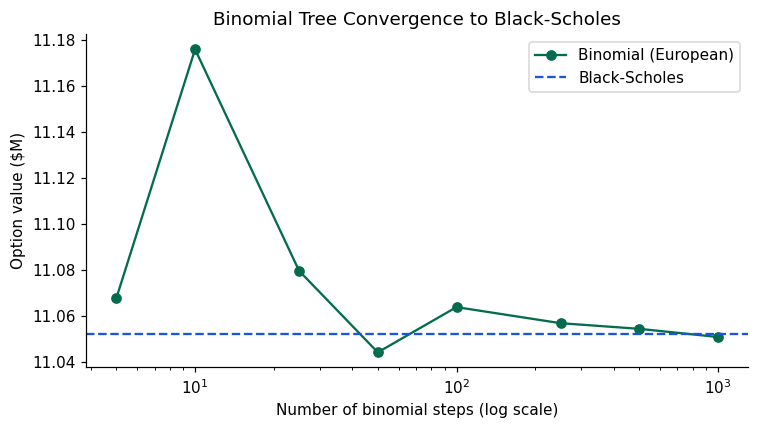

In [5]:
step_counts = [5, 10, 25, 50, 100, 250, 500, 1000]
convergence = [binomial_call(S_synergy, K_capex, r_rf, T_years, sigma_synergy, n) for n in step_counts]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(step_counts, convergence, marker="o", color=COLOR_OPTION, label="Binomial (European)")
ax.axhline(real_option_value, color=COLOR_BASE, linestyle="--", label="Black-Scholes")
ax.set_xscale("log")
ax.set_xlabel("Number of binomial steps (log scale)")
ax.set_ylabel("Option value ($M)")
ax.set_title("Binomial Tree Convergence to Black-Scholes")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Earn-Out Simulation (Monte Carlo)

If the seller wants a higher price, the gap is often bridged with an
earn-out: pay the base price now, plus a bonus later if a target (usually
EBITDA or synergy value) is hit.

Model EBITDA/synergy with **Geometric Brownian Motion**:

$$dE_t = \mu E_t\, dt + \sigma E_t\, dW_t \quad\Longrightarrow\quad
E_t = E_0 \exp\!\left[\left(\mu - \tfrac{1}{2}\sigma^2\right)t + \sigma W_t\right]$$

Simulate thousands of paths to estimate:

$$P(\text{target hit}) = P\!\left(E_T \ge \text{Hurdle}\right), \qquad
\text{Expected PV of earn-out} = e^{-rT}\,\mathbb{E}\left[\text{Bonus} \cdot \mathbb{1}\{E_T \ge \text{Hurdle}\}\right]$$

In [6]:
def simulate_gbm_paths(E0, mu, sigma, T, n_steps, n_paths, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    increments = (mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * rng.standard_normal((n_paths, n_steps))
    log_paths = np.log(E0) + np.cumsum(increments, axis=1)
    log_paths = np.hstack([np.full((n_paths, 1), np.log(E0)), log_paths])
    return np.exp(log_paths)


# Illustrative earn-out inputs
E0 = 23.96                  # $M, starting synergy/EBITDA, calibrated for ~72% probability
hurdle = 20.0               # $M, EBITDA/synergy target
mu_drift = 0.12             # expected annual growth 12%
sigma_mc = 0.35             # volatility, same as the option section
T_earnout = 3.0             # earn-out horizon, 3 years
earn_out_bonus = 50.0       # $M, bonus paid if target is hit
n_paths = 10_000
n_steps = 36                # monthly steps over 3 years

paths = simulate_gbm_paths(E0, mu_drift, sigma_mc, T_earnout, n_steps, n_paths)
terminal_values = paths[:, -1]

hit_mask = terminal_values >= hurdle
hit_probability = hit_mask.mean()

expected_payout = earn_out_bonus * hit_mask
pv_expected_earnout = np.exp(-r_rf * T_earnout) * expected_payout.mean()

print(f"Number of simulations:         {n_paths:,}")
print(f"Earn-out hurdle:                ${hurdle:,.1f}M")
print(f"Probability target is hit (T={T_earnout:.0f}y): {hit_probability:.1%}")
print(f"Expected PV of earn-out cost:   ${pv_expected_earnout:,.2f}M")

Number of simulations:         10,000
Earn-out hurdle:                $20.0M
Probability target is hit (T=3y): 71.8%
Expected PV of earn-out cost:   $31.85M


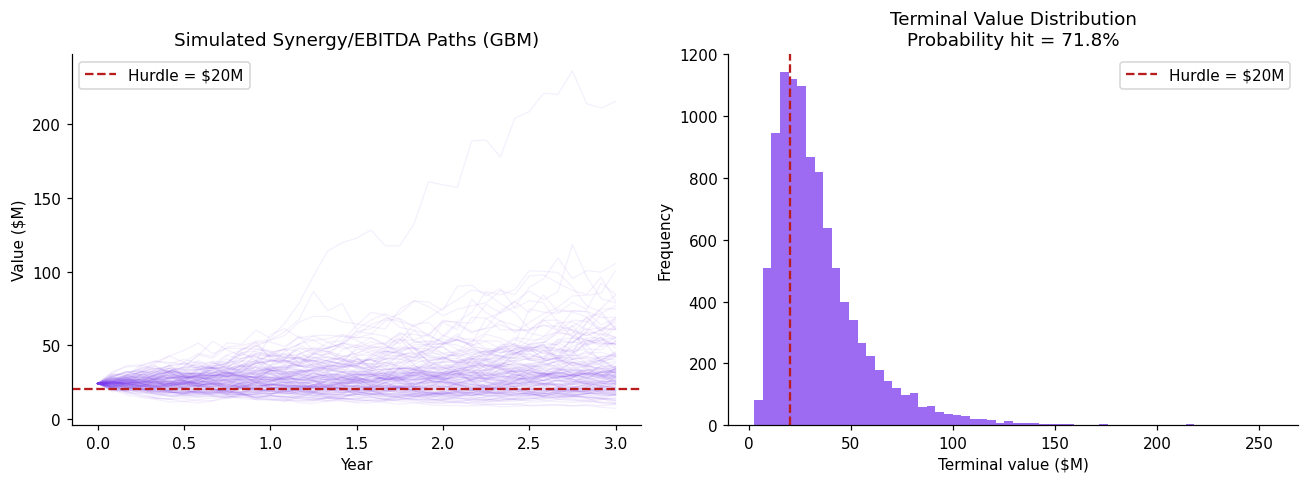

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: sample simulated paths
sample_idx = np.random.choice(n_paths, 150, replace=False)
time_grid = np.linspace(0, T_earnout, n_steps + 1)
for i in sample_idx:
    axes[0].plot(time_grid, paths[i], color=COLOR_ACCENT, alpha=0.08, linewidth=0.8)
axes[0].axhline(hurdle, color="#b91c1c", linestyle="--", linewidth=1.5, label=f"Hurdle = ${hurdle:.0f}M")
axes[0].set_title("Simulated Synergy/EBITDA Paths (GBM)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Value ($M)")
axes[0].legend()

# Right: terminal value distribution
axes[1].hist(terminal_values, bins=60, color=COLOR_ACCENT, alpha=0.75)
axes[1].axvline(hurdle, color="#b91c1c", linestyle="--", linewidth=1.5, label=f"Hurdle = ${hurdle:.0f}M")
axes[1].set_title(f"Terminal Value Distribution\nProbability hit = {hit_probability:.1%}")
axes[1].set_xlabel("Terminal value ($M)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Sensitivity Matrix

Testing two key assumptions against **total acquisition price**
($NPV_{\text{standalone}} + C$):

- **Synergy volatility ($\sigma$)** — more uncertain synergy raises option value
- **Integration speed** — modeled as time to the expansion decision ($T$).
  Faster integration = shorter window; slower = longer window but a
  pricier option

In [8]:
sigma_grid = np.array([0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50])
T_grid = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 4.0])   # time to expansion decision (proxy for integration speed)

sensitivity = np.zeros((len(T_grid), len(sigma_grid)))
for i, T_i in enumerate(T_grid):
    for j, sig_j in enumerate(sigma_grid):
        call_val, _, _ = black_scholes_call(S_synergy, K_capex, r_rf, T_i, sig_j)
        sensitivity[i, j] = npv_standalone + call_val

sens_df = pd.DataFrame(
    sensitivity,
    index=[f"{t:.1f}y" for t in T_grid],
    columns=[f"{s:.0%}" for s in sigma_grid],
)
sens_df.index.name = "Expansion Decision Time (proxy for integration speed)"
sens_df.columns.name = "Synergy Volatility (sigma)"
sens_df.round(2)

Synergy Volatility (sigma),15%,20%,25%,30%,35%,40%,50%
Expansion Decision Time (proxy for integration speed),,,,,,,
1.0y,106.30,106.52,106.84,107.21,107.62,108.06,108.98
1.5y,106.86,107.19,107.61,108.10,108.62,109.17,110.30
2.0y,107.40,107.80,108.32,108.89,109.50,110.13,111.42
2.5y,107.92,108.39,108.97,109.61,110.29,110.99,112.41
3.0y,108.42,108.94,109.57,110.27,111.01,111.77,113.30
4.0y,109.36,109.96,110.69,111.48,112.31,113.16,114.85


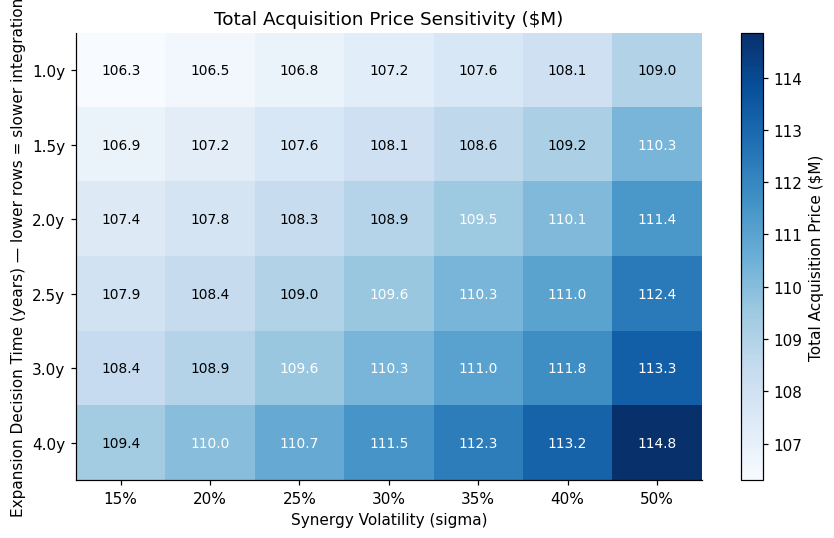

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(sensitivity, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(sigma_grid)))
ax.set_xticklabels([f"{s:.0%}" for s in sigma_grid])
ax.set_yticks(range(len(T_grid)))
ax.set_yticklabels([f"{t:.1f}y" for t in T_grid])
ax.set_xlabel("Synergy Volatility (sigma)")
ax.set_ylabel("Expansion Decision Time (years) — lower rows = slower integration")
ax.set_title("Total Acquisition Price Sensitivity ($M)")

for i in range(len(T_grid)):
    for j in range(len(sigma_grid)):
        ax.text(j, i, f"{sensitivity[i, j]:.1f}", ha="center", va="center",
                color="white" if sensitivity[i, j] > sensitivity.mean() else "black", fontsize=9)

fig.colorbar(im, ax=ax, label="Total Acquisition Price ($M)")
plt.tight_layout()
plt.show()

## 6. Summary

Combine the DCF, option value, and earn-out probability into one chart and table.

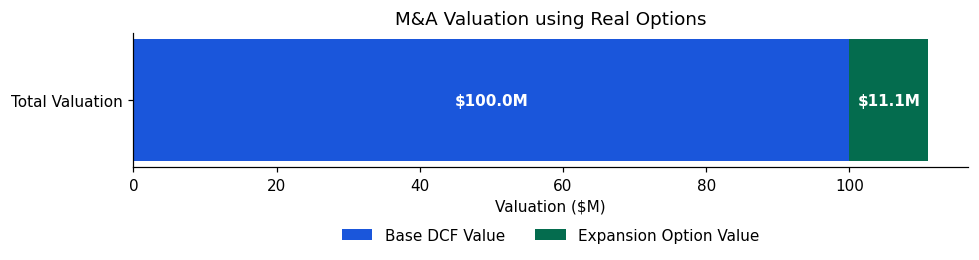

,Metric,Value,Notes
0,Base DCF,$99.96M,Standalone target valuation (discounted cash f...
1,Expansion Option Value,$11.05M,"Black-Scholes call C(S, K, r, T, sigma)"
2,Total Acquisition Price,$111.01M,Base DCF + expansion option value
3,Expansion Capex (Strike K),$25.00M,Investment needed to unlock synergy
4,Probability Earn-Out is Hit,71.8%,Probability synergy/EBITDA >= hurdle $20M
5,Expected PV of Earn-Out Cost,$31.85M,From Monte Carlo simulation


In [10]:
fig, ax = plt.subplots(figsize=(9, 2.8))

ax.barh(["Total Valuation"], [npv_standalone], color=COLOR_BASE, label="Base DCF Value")
ax.barh(["Total Valuation"], [real_option_value], left=[npv_standalone], color=COLOR_OPTION,
        label="Expansion Option Value")

ax.text(npv_standalone / 2, 0, f"${npv_standalone:,.1f}M", ha="center", va="center",
        color="white", fontweight="bold")
ax.text(npv_standalone + real_option_value / 2, 0, f"${real_option_value:,.1f}M", ha="center", va="center",
        color="white", fontweight="bold")

ax.set_xlabel("Valuation ($M)")
ax.set_title("M&A Valuation using Real Options")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

summary = pd.DataFrame([
    ["Base DCF", f"${npv_standalone:,.2f}M", "Standalone target valuation (discounted cash flow)"],
    ["Expansion Option Value", f"${real_option_value:,.2f}M", "Black-Scholes call C(S, K, r, T, sigma)"],
    ["Total Acquisition Price", f"${npv_standalone + real_option_value:,.2f}M", "Base DCF + expansion option value"],
    ["Expansion Capex (Strike K)", f"${K_capex:,.2f}M", "Investment needed to unlock synergy"],
    ["Probability Earn-Out is Hit", f"{hit_probability:.1%}", f"Probability synergy/EBITDA >= hurdle ${hurdle:.0f}M"],
    ["Expected PV of Earn-Out Cost", f"${pv_expected_earnout:,.2f}M", "From Monte Carlo simulation"],
], columns=["Metric", "Value", "Notes"])

summary

### Conclusion

- The expansion option adds **~$11M** over the base DCF — a reasonable
  ceiling for any premium paid for this right.
- **Binomial tree closely matches Black-Scholes**, confirming the result.
- **~72% chance the earn-out is hit** — the bonus is an expected cost, not
  a free upside for the seller.
- Option value is **most sensitive to synergy volatility**. Reducing that
  uncertainty (e.g. via a pilot project) makes the option cheaper and the
  deal safer.

### Next steps

1. Replace illustrative assumptions (FCFF, WACC, volatility) with real
   target financials.
2. Test different earn-out hurdle definitions (EBITDA vs revenue vs
   synergy PV) — the choice can shift the hit probability significantly.
3. Pair the sensitivity matrix with a standard accretion/dilution
   analysis.

---
*Personal project exploring real options in M&A — assumptions are meant
to be adapted, not taken at face value.*